# **The [online retail shop](https://archive.ics.uci.edu/dataset/352/online+retail) analysis.**
It requires feature scaling and engineering to extract useful insights for real retail processes.

# **1.   Importing necessary libraries and loading the dataset.**

In [ ]:
import sklearn as sk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pprint
import datetime

In [ ]:
from google.colab import drive
drive.mount("drive")

Mounted at drive


In [ ]:
df = pd.read_excel("drive/MyDrive/online_retail.xlsx")

# **2.   Explatory Data Analysis (EDA)**
  *   Data types are checked
  *   DataFrame is partly printed

  to have the overall understanding of the dataset

In [ ]:
print(df.info(), "\n\n----Dataset's top 5 columns----")
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None 

----Dataset's top 5 columns----


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# **3.   Data cleaning**


In [ ]:
# checked NaN values for each column
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
# unique values count by each column
def unique_values(x):
  return len(df[x].unique())

pprint.pprint({c: unique_values(c) for c in df.columns})

{'Country': 38,
 'CustomerID': 4373,
 'Description': 4224,
 'InvoiceDate': 23260,
 'InvoiceNo': 25900,
 'Quantity': 722,
 'StockCode': 4070,
 'UnitPrice': 1630}


In [ ]:
null_customers = df[df["CustomerID"].isna()]

print("Countries with most customers not identified:\n", null_customers["Country"].value_counts(), "\n\n")

print("The most expensive purchase:", max(null_customers["Quantity"]*null_customers["UnitPrice"]))
print("Average purchase:", max(null_customers["Quantity"]*null_customers["UnitPrice"]))
print("\n\n\n", null_customers[['Quantity','UnitPrice']].describe())

# it's natural to see most of the unidentified customer are from UK where the retail store is located

Countries with most customers not identified:
 Country
United Kingdom    133600
EIRE                 711
Hong Kong            288
Unspecified          202
Switzerland          125
France                66
Israel                47
Portugal              39
Bahrain                2
Name: count, dtype: int64 


The most expensive purchase: 13541.33
Average purchase: 13541.33



             Quantity      UnitPrice
count  135080.000000  135080.000000
mean        1.995573       8.076577
std        66.696153     151.900816
min     -9600.000000  -11062.060000
25%         1.000000       1.630000
50%         1.000000       3.290000
75%         3.000000       5.450000
max      5568.000000   17836.460000


In [ ]:
nan_customerid = df[(df["InvoiceNo"].notna())&(df["InvoiceDate"].notna())&(df['CustomerID'].isna())]

In [ ]:
# done for safety sake, in this case to fill NaN customerID cells of dataframe where respective
condition1 = df["InvoiceNo"].isin(nan_customerid["InvoiceNo"]) #  and Invoice Numbers
condition2 = df["InvoiceDate"].isin(nan_customerid["InvoiceDate"]) # Invoice Date aren't NaN,
condition3 = df["CustomerID"].notna()

df[(condition1)&(condition2)&(condition3)] # at the end, it didn't work.

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [ ]:
# as the retail store dataset is used for customer behavious understanding it is better to emphasise the
# customers with no unidentified metrics
df = df.dropna(subset=["CustomerID"])
requirement1 = (df["UnitPrice"]>0)
requirement2 = (df["Quantity"]>0)
requirement3 = (df["InvoiceNo"].astype(str).str.startswith("C") == False)
df = df[requirement1 & requirement2 & requirement3]

# **4.   Feature engineering**
Columns are changed in a way to yield useful insights later

In [ ]:
df["Total"] = df["UnitPrice"] * df["Quantity"] # column to show each set of item's purchase added

In [ ]:
processing_date = df["InvoiceDate"].max() + datetime.timedelta(days=1) # as the dataset shows condition more than decade ago, I decided to
# bring the date closer to its collection time, one day after the last invoice
df["TillNow"] = (processing_date - df["InvoiceDate"]).dt.days
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total,TillNow
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,374
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,374
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,374
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,374
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,374


In [ ]:
rfm = df.groupby("CustomerID").agg(
    recency=("TillNow", "mean"),
    frequency=("InvoiceNo", "nunique"),
    monetary=("Total", "sum")).reset_index() #this dataframe shows the frequency, number and total amount of purchases for each customer

In [ ]:
rfm

,CustomerID,recency,frequency,monetary
0,12346.0,326.000000,1,77183.60
1,12347.0,189.857143,7,4310.00
2,12348.0,305.483871,4,1797.24
3,12349.0,19.000000,1,1757.55
4,12350.0,310.000000,1,334.40
...,...,...,...,...
4333,18280.0,278.000000,1,180.60
4334,18281.0,181.000000,1,80.82
4335,18282.0,76.833333,2,178.05
4336,18283.0,134.632275,16,2094.88


# **5.   Data preprocessing**
Data is processed to be used for model

In [ ]:
rfm_columns = rfm.columns.to_list()
decisive_columns = rfm_columns[1:]
decisive_columns # columns for this processes are chosen

['recency', 'frequency', 'monetary']

In [ ]:
scaler = sk.preprocessing.StandardScaler()
rfm_scaled = rfm.copy()
rfm_scaled[rfm_columns[1:]] = scaler.fit_transform(rfm_scaled[rfm_columns[1:]])
rfm_scaled  # data is scaled ensuring there will be no serious errors at the end

,CustomerID,recency,frequency,monetary
0,12346.0,1.890678,-0.425097,8.358668
1,12347.0,0.379313,0.354417,0.250966
2,12348.0,1.662922,-0.035340,-0.028596
3,12349.0,-1.517428,-0.425097,-0.033012
4,12350.0,1.713057,-0.425097,-0.191347
...,...,...,...,...
4333,18280.0,1.357815,-0.425097,-0.208459
4334,18281.0,0.280987,-0.425097,-0.219560
4335,18282.0,-0.875401,-0.295178,-0.208742
4336,18283.0,-0.233756,1.523687,0.004519


# **6.   Optimal k selection**
Best cluster amount is chosen to split customer as category

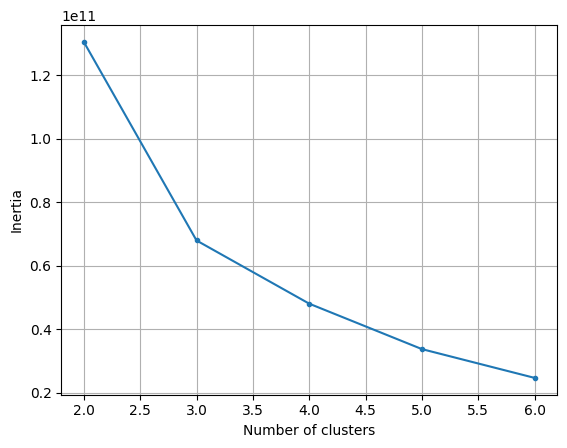

In [ ]:
inertia = []
chosen_range = range(2, 7)

for k in chosen_range:
  km = sk.cluster.KMeans(n_clusters=k, n_init=10, random_state=42)
  km.fit(rfm)
  inertia.append(km.inertia_)
plt.plot(chosen_range, inertia, marker=".")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.grid()
plt.show()

# **7.   Model training**
The borders of groups to split customers into is calculated

In [ ]:
k = 3 # in the graph above the variance stopped dropping significantly from 3 on, so customers are split into 3 groups
km = sk.cluster.KMeans(n_clusters=k, n_init=10, random_state=42)
km.fit(rfm_scaled[rfm_columns[1:]])
rfm["Cluster"] = km.predict(rfm_scaled[rfm_columns[1:]])
rfm["Cluster"].value_counts().reset_index()

,Cluster,count
0,0,2213
1,2,2099
2,1,26


In [ ]:
rfm

,CustomerID,recency,frequency,monetary,Cluster
0,12346.0,326.000000,1,77183.60,0
1,12347.0,189.857143,7,4310.00,0
2,12348.0,305.483871,4,1797.24,0
3,12349.0,19.000000,1,1757.55,2
4,12350.0,310.000000,1,334.40,0
...,...,...,...,...,...
4333,18280.0,278.000000,1,180.60,0
4334,18281.0,181.000000,1,80.82,0
4335,18282.0,76.833333,2,178.05,2
4336,18283.0,134.632275,16,2094.88,0


In [ ]:
rfm_summary = rfm.groupby("Cluster").agg(Recency=("recency", "mean"), Frequency=("frequency", "mean"), Monetary=("monetary", "mean"), Total=("monetary", "sum"), Count=("Cluster", "count")).reset_index()
rfm_summary["AveragePurchase"] = rfm_summary["Monetary"]/rfm_summary["Frequency"]
rfm_summary.round(1)

,Cluster,Recency,Frequency,Monetary,Total,Count,AveragePurchase
0,0,226.9,5.0,2052.0,4541061.0,2213,413.1
1,1,161.4,66.4,85904.4,2233513.1,26,1293.3
2,2,80.5,2.8,1018.0,2136833.7,2099,367.7


# **9.   Cluster interpretation**
Customers are classified based on the results on K-means model

In [ ]:
rfm["Cluster"] = rfm["Cluster"].map({1: "VIP", 2: "Casual", 0: "At Risk"})

In [ ]:
rfm

,CustomerID,recency,frequency,monetary,Cluster
0,12346.0,326.000000,1,77183.60,At Risk
1,12347.0,189.857143,7,4310.00,At Risk
2,12348.0,305.483871,4,1797.24,At Risk
3,12349.0,19.000000,1,1757.55,Casual
4,12350.0,310.000000,1,334.40,At Risk
...,...,...,...,...,...
4333,18280.0,278.000000,1,180.60,At Risk
4334,18281.0,181.000000,1,80.82,At Risk
4335,18282.0,76.833333,2,178.05,Casual
4336,18283.0,134.632275,16,2094.88,At Risk


In [ ]:
# new column "Cluster" that indicates group added
all_columns = df.columns.to_list()
all_columns.append("Cluster")
df = df.merge(rfm, on="CustomerID", how="inner")[all_columns]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total,TillNow,Cluster
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,374,At Risk
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,374,At Risk
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,374,At Risk
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,374,At Risk
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,374,At Risk


In [ ]:
clusters = df["Cluster"].unique()

In [ ]:
cc_df = df.groupby(["Cluster", "Country"])["CustomerID"].nunique().reset_index(name="CustomerCount").sort_values(["Cluster", "Country"], ascending=False)
cc_df

,Cluster,Country,CustomerCount
65,VIP,United Kingdom,22
64,VIP,Netherlands,1
63,VIP,EIRE,2
62,VIP,Australia,1
61,Casual,Unspecified,2
...,...,...,...
4,At Risk,Brazil,1
3,At Risk,Belgium,16
2,At Risk,Bahrain,2
1,At Risk,Austria,6


    Cluster         Country  CustomerCount
65      VIP  United Kingdom             22
63      VIP            EIRE              2
64      VIP     Netherlands              1
62      VIP       Australia              1
60   Casual  United Kingdom           1903
44   Casual         Germany             45
43   Casual          France             43
55   Casual           Spain             13
57   Casual     Switzerland             11
33  At Risk  United Kingdom           1995
14  At Risk         Germany             49
13  At Risk          France             44
28  At Risk           Spain             17
3   At Risk         Belgium             16


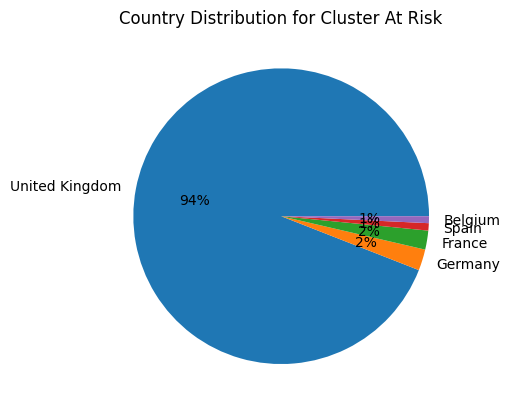

    Cluster         Country  CustomerCount
33  At Risk  United Kingdom           1995
14  At Risk         Germany             49
13  At Risk          France             44
28  At Risk           Spain             17
3   At Risk         Belgium             16


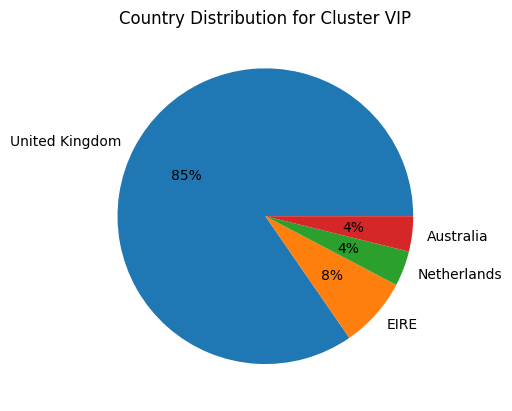

   Cluster         Country  CustomerCount
65     VIP  United Kingdom             22
63     VIP            EIRE              2
64     VIP     Netherlands              1
62     VIP       Australia              1


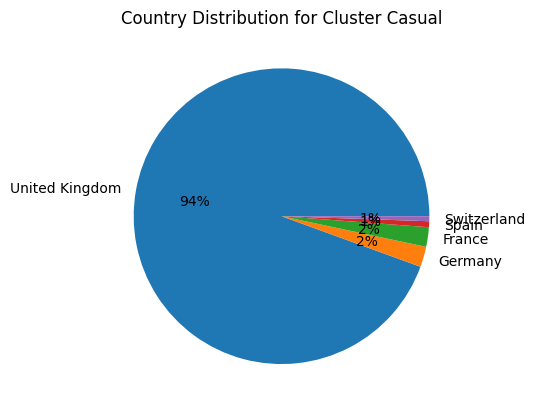

   Cluster         Country  CustomerCount
60  Casual  United Kingdom           1903
44  Casual         Germany             45
43  Casual          France             43
55  Casual           Spain             13
57  Casual     Switzerland             11


In [ ]:
cctop5_df = cc_df.sort_values(["Cluster", "CustomerCount"], ascending=[False, False]).groupby("Cluster").head(5)
print(cctop5_df)
for cluster in clusters:
  plt.pie(
      cctop5_df[cctop5_df["Cluster"] == cluster]["CustomerCount"],
      labels=cctop5_df[cctop5_df["Cluster"] == cluster]["Country"],
      autopct='%.0f%%',
      radius=1.0)
  plt.title(f"Country Distribution for Cluster {cluster}")
  plt.show()
  print(cctop5_df[cctop5_df["Cluster"] == cluster])

In [ ]:
cc_df = df.groupby(["Cluster", "Country"]).nunique("CustomerID")["CustomerID"].reset_index(name="VIPcount")
vip_countdf = cc_df[cc_df["Cluster"] == "VIP"]
print(vip_countdf)
cus_countdf = cc_df.groupby("Country").sum("VIPcount").reset_index()
cus_countdf
vip_sharedf = vip_countdf.merge(cus_countdf, on="Country", how="left")
vip_sharedf
vip_sharedf["VipShare"] = (vip_sharedf["VIPcount_x"]/ vip_sharedf["VIPcount_y"]).round(2)
vip_sharedf.sort_values(by=["VipShare", "VIPcount_y"], ascending=[False, True]) #this shows the countries with the highest VIP ratio

   Cluster         Country  VIPcount
62     VIP       Australia         1
63     VIP            EIRE         2
64     VIP     Netherlands         1
65     VIP  United Kingdom        22


,Cluster,Country,VIPcount_x,VIPcount_y,VipShare
1,VIP,EIRE,2,3,0.67
0,VIP,Australia,1,9,0.11
2,VIP,Netherlands,1,9,0.11
3,VIP,United Kingdom,22,3920,0.01


In [ ]:
cc_df

,Cluster,Country,CustomerCount
0,At Risk,Australia,7
1,At Risk,Austria,6
2,At Risk,Bahrain,2
3,At Risk,Belgium,16
4,At Risk,Brazil,1
...,...,...,...
61,Casual,Unspecified,2
62,VIP,Australia,1
63,VIP,EIRE,2
64,VIP,Netherlands,1


In [ ]:
import pandas as pd

# small example dataset
data = {
    "client_id": [1, 1, 2, 3, 4, 5, 5, 6],
    "nation": ["UK", "UK", "UK", "France", "Germany", "Germany", "Germany", "UK"],
    "segment": ["A", "A", "A", "A", "B", "B", "B", "B"]
}

sales_df = pd.DataFrame(data)

# unique customers per nation inside each segment
result = (
    sales_df
    .groupby(["segment", "nation"])["client_id"]
    .nunique()
    .reset_index(name="unique_clients")
    .sort_values(["segment", "unique_clients"], ascending=[True, False])
)

print(result)

In [ ]:
df.groupby(["Cluster", "Country"]).count()

# **Insights from this dataset:**

*   VIP customers have bought worth of close to 30% of total monetary amount despite being lower than 1% of total customer base 💰;
*   This group deserve particular attention with exclusive discounts🌟;
*   At Risk group should be targeted to further improve sales with re-engagement campaigns because it is the one with most purchasing power 🎯;
*   Retailer should also work on making Casual buyers buy more expensive purchases 🧲.